# ***packages***

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scanpy as sc
import numpy as np
import pandas as pd
import os
from sklearn.metrics.pairwise import euclidean_distances
from sklearn import svm
from sklearn.preprocessing import MinMaxScaler
import pickle
import mygene
import anndata
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import random
from glob import glob



# ***data***

In [2]:
def load_data(data_dir, data1, data2, show=True):    

    sliceA = sc.read_h5ad(data_dir + data1 + ".h5ad")
    sliceB = sc.read_h5ad(data_dir + data2 + ".h5ad")

    xI = np.array(sliceA.obsm['spatial'] [:, 0])
    yI = np.array(sliceA.obsm['spatial'] [:, 1])

    xJ = np.array(sliceB.obsm['spatial'] [:, 0])
    yJ = np.array(sliceB.obsm['spatial'] [:, 1])

    plt.scatter(xI,yI,s=1,alpha=1, label='source')
    plt.axis("off")
    plt.legend()
    if show:
        plt.show()

    plt.scatter(xJ,yJ,s=1,alpha=1, c='#ff7f0e',  label='target')
    plt.axis("off")
    plt.legend()
    if show:
        plt.show()
    plt.gca()
    plt.close()
    return sliceA, sliceB

# ***Age Progression Score***

*Note: Make sure the run the alignment for the respective dataset before running this code. This code requires the cosine distance of gene expression and the pi matrix that will be stored to `local_data` directory once you run the alignment pipeline.*

In [3]:
def compute_age_progression_score(sliceA, sliceB, data1, data2, filePath):
    '''
    Compute age progression score for each slice and return the score in the obs column of the slice
    '''

    cosine_dist_gene_expr = np.load(f"{filePath}/cosine_dist_gene_expr_{data1}_{data2}.npy")
    pi_mat = np.load(f"{filePath}/pi_matrix_{data1}_{data2}.npy")

    age_progression_score_mat = pi_mat * cosine_dist_gene_expr

    sliceA.obs['age_progression_score'] = np.sum(age_progression_score_mat, axis=1, dtype=np.float64) / (1 / sliceA.n_obs) * 100
    sliceB.obs['age_progression_score'] = np.sum(age_progression_score_mat, axis=0, dtype=np.float64) / (1 / sliceB.n_obs) * 100

    return sliceA, sliceB

In [4]:
def filter_cells_by_count(adata, threshold):
    '''
    Filter out cells with cell type count less than threshold
    '''

    cell_type_counts = adata.obs['cell_type_annot'].value_counts()
    valid_cell_types = cell_type_counts[cell_type_counts >= threshold].index.tolist()

    return adata[adata.obs['cell_type_annot'].isin(valid_cell_types)]

In [5]:
def get_color_map(sliceA):

    import random
    random.seed(82)
    def generate_random_colors(num_colors):
        colors = []
        for _ in range(num_colors):
            colors.append((random.random(), random.random(), random.random()))
        return colors

    unique_cell_types = sliceA.obs['cell_type_annot'].unique()
    random_colors = generate_random_colors(len(unique_cell_types))

    color_map = dict(zip(unique_cell_types, random_colors))
    return color_map


In [6]:
def plot_age_progression_score_boxplot(sliceA, age_start, age_end, color_map, save_file_loc, show=True):
    sliceA = filter_cells_by_count(sliceA, threshold=10)
    
    sns.boxplot(x="cell_type_annot", y="age_progression_score", 
                data=sliceA.obs,
                palette = color_map.values(), hue = sliceA.obs['cell_type_annot'], 
                notch=False, showcaps=False, flierprops={"marker": "d"},)
    plt.xlabel("")
    plt.ylabel("Age Progression Score")
    plt.xticks(rotation=45)
    plt.title(f"Variability in age progression score for different cell types.\nTransition from {age_start} weeks to {age_end} weeks")
    plt.savefig(save_file_loc, bbox_inches='tight', format='jpg')
    if show == True:
        plt.show()
    plt.gca()
    plt.close()
    


# ***Neighborhood count on Age progression score***

In [7]:

def get_neighborhood_distribution(curr_slice, radius):

    unique_cell_types = np.array(list(curr_slice.obs['cell_type_annot'].unique()))
    cell_type_to_index = dict(zip(unique_cell_types, list(range(len(unique_cell_types)))))
    cells_within_radius = np.zeros((curr_slice.shape[0], len(unique_cell_types)), dtype=float)

    source_coords = curr_slice.obsm['spatial']
    distances = euclidean_distances(source_coords, source_coords)

    for i in range(curr_slice.shape[0]):
        # find the indices of the cells within the radius

        target_indices = np.where(distances[i] <= radius)[0]

        for ind in target_indices:
            cell_type_str_j = str(curr_slice.obs['cell_type_annot'][ind])
            cells_within_radius[i][cell_type_to_index[cell_type_str_j]] += 1

    return np.array(cells_within_radius)


### Linear Regression

In [8]:

def run_relation_betwn_neighbor_age_prog_score(sliceA, age_start, age_end, save_dir):
    '''
    Run linear regression between the number of neighboring cells and the age progression score
    Save the results and plots in the save_dir
    '''
    relation_save_dir = f'{save_dir}/age-prog-score/relation/{age_start}_{age_end}'

    if not os.path.exists(f'{relation_save_dir}'):
        os.makedirs(f'{relation_save_dir}')
        
    with open(f'{relation_save_dir}/linear_regression_results_{age_start}_{age_end}.txt', 'w') as f:
        f.write(f"Linear Regression (R2) scores for transition from {age_start} to {age_end}\n\n")

    neighborhood_counts = get_neighborhood_distribution(sliceA, 100)
    unique_cell_types = np.array(list(sliceA.obs['cell_type_annot'].unique()))

    for k in range(unique_cell_types.shape[0]):    
        for j in range(unique_cell_types.shape[0]):
            X = []
            y = []
            for i in range(sliceA.n_obs):
            
                if sliceA.obs['cell_type_annot'].iloc[i] == unique_cell_types[k]:
                    X.append(neighborhood_counts[i][j])
                    y.append(sliceA.obs['age_progression_score'].iloc[i])

            X = np.array(X).reshape(-1, 1)
            y = np.array(y).reshape(-1, 1)  

            # Fit the linear regression model
            regressor = LinearRegression()
            regressor.fit(X, y)
            # Predict the age_progression_score based on the count of neighboring cells
            y_pred = regressor.predict(X)

            plt.scatter(X, y, color='red')
            plt.plot(X, y_pred, color='gray')
            # plt.title(f'Linear Regression between {unique_cell_types[k]} vs {unique_cell_types[j]}')
            plt.xlabel('Number of neighboring cells')
            plt.ylabel('Age Progression Score')
            plt.savefig(f'{relation_save_dir}/{unique_cell_types[k]}_{unique_cell_types[j]}.png', bbox_inches='tight')
            plt.clf()

            # Calculate the R2 score
            r2 = r2_score(y, y_pred)

            # write to file
            with open(f'{relation_save_dir}/linear_regression_results_{age_start}_{age_end}.txt', 'a') as f:
                f.write(f"{unique_cell_types[k]} and {unique_cell_types[j]} \t {r2}\n")
            
                    
    print("Linear regression plots and results are saved in ", relation_save_dir)


# ***Spatial DE***

In [9]:

def filter_cells_by_cell_type(sliceA, cell_type):
    filtered_adata = sliceA[sliceA.obs['cell_type_annot'] == cell_type].copy()
    return filtered_adata

def run_spatialde(sliceA, cell_type, save_path):
    import NaiveDE
    import SpatialDE
    counts = pd.DataFrame(sliceA.obs['age_progression_score'], columns=['age_progression_score'])

    sample_info = pd.DataFrame(sliceA.obsm['spatial'], columns=['x', 'y'])
    sample_info['total_counts'] = counts.to_numpy()

    norm_expr = NaiveDE.stabilize(counts.T).T
    resid_expr = NaiveDE.regress_out(sample_info, norm_expr.T, 'np.log(total_counts)').T

    resid_expr['log_total_count'] = np.log(sample_info['total_counts'])

    X = sample_info[['x', 'y']].to_numpy()
    results = SpatialDE.run(X, resid_expr)

    results.to_csv(f'./{save_path}/spatial_de_age_results_{cell_type}.csv', index=False)

In [10]:
def run_spatialde_analysis(sliceA, age, save_dir):
    '''
    Run spatialDE analysis for each cell type in the sliceA
    Save the results in the save_dir
    '''
    sliceA = filter_cells_by_count(sliceA, 10)

    spatialde_save_dir = f'{save_dir}/spatialde/{age}'
    if not os.path.exists(f'{spatialde_save_dir}'):
        os.makedirs(f'{spatialde_save_dir}')

    unique_cell_types = sliceA.obs['cell_type_annot'].unique()
    for cell_type in unique_cell_types:
        print(f'\n\nRunning spatialDE for {cell_type}')
        sliceA_cell_type = filter_cells_by_cell_type(sliceA, cell_type)
        try:
            run_spatialde(sliceA_cell_type, cell_type, save_path=spatialde_save_dir)
        except:
            print(f'Error in running spatialDE for {cell_type}')
            continue

    print("SpatialDE results are saved in ", spatialde_save_dir)


# ***SVR Model***

In [11]:
def evaluate_regression(Y_true, Y_pred):
    '''Returns the R^2 score for the regression model'''
    
    Y_true = np.array(Y_true)
    Y_pred = np.array(Y_pred)

    # Mean Absolute Error
    mae = np.mean(np.abs(Y_true - Y_pred))

    # Mean Squared Error
    mse = np.mean((Y_true - Y_pred) ** 2)

    # Root Mean Squared Error
    rmse = np.sqrt(mse)

    # R^2
    ss_res = np.sum((Y_true - Y_pred) ** 2)
    ss_tot = np.sum((Y_true - np.mean(Y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    return r2


In [12]:
def svr_model(adata_train, adata_test):
    # uses cell_type one hot encoding with augmented cellular neighborhood matrix and gene expr as feature matrix
    
    radius = 100
    model = svm.SVR(kernel='linear')

    one_hot = pd.get_dummies(adata_train.obs['cell_type_annot'], dtype=int).values

    X_train = np.concatenate((one_hot, get_neighborhood_distribution(adata_train, radius), adata_train.X), axis=1)

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)

    y_train = adata_train.obs['age_progression_score'].values

    one_hot = pd.get_dummies(adata_test.obs['cell_type_annot'], dtype=int).values

    X_test = np.concatenate((one_hot, get_neighborhood_distribution(adata_test, radius), adata_test.X), axis=1)
    X_test = scaler.transform(X_test)

    y_test = adata_test.obs['age_progression_score'].values

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)

    train_r2 = evaluate_regression(y_train, y_pred_train)
    # print("Training outputs:")
    # print("r2: ", train_r2)

    y_pred_test = model.predict(X_test)

    test_r2 = evaluate_regression(y_test, y_pred_test)
    # print("Test outputs:")
    # print("r2: ", test_r2)

    return model, train_r2, test_r2


In [13]:
def train_test_split_by_cell_type(adata, test_size=0.2):
    # randomly take 20% data from each cell-types to form train data and the rest to train data

    adata = filter_cells_by_count(adata = adata, threshold = 10)

    # Get the unique cell types
    unique_cell_types = adata.obs['cell_type_annot'].unique()

    # Create empty lists for train and test data
    adata_train_list = []
    adata_test_list = []

    # Iterate over each cell type
    for cell_type in unique_cell_types:
        # Get the indices of cells of the current cell type
        cell_type_indices = np.where(adata.obs['cell_type_annot'] == cell_type)[0]

        # Randomly select test indices
        random.seed(82)
        test_indices = random.sample(list(cell_type_indices), int(len(cell_type_indices) * test_size))

        # Add the remaining indices to train data
        train_indices = list(set(cell_type_indices) - set(test_indices))

        # Append the train and test data to the respective lists
        adata_train_list.append(adata[train_indices, :])
        adata_test_list.append(adata[test_indices, :])

    # Concatenate the train and test data
    adata_train = anndata.concat(adata_train_list)
    adata_test = anndata.concat(adata_test_list)

    return adata_train, adata_test


In [14]:

def get_gene_names(gene_IDs):
    print("getting gene names from ensembl_id")
    mg = mygene.MyGeneInfo()
    gene_names = []
    for ensembl_id in gene_IDs:
        gene_info = mg.getgene(ensembl_id)
        if gene_info:
            gene_name = gene_info['symbol']
            gene_names.append(gene_name)
        else:
            print(f"Warning: Gene not found for ID: {ensembl_id}")

    return gene_names

In [15]:
def run_model(sliceA, data1, save_path):
    train_data, test_data = train_test_split_by_cell_type(sliceA)

    svrModel, train_r2, test_r2 = svr_model(train_data, test_data)
    # save the model
    modelFile = f'{save_path}/svr_model_{data1}.pkl'
    pickle.dump(svrModel, open(modelFile, 'wb'))

    sliceA_mod = filter_cells_by_count(adata = sliceA, threshold = 10)

    gene_names = get_gene_names(sliceA_mod.var_names)
    gene_names = ["gene-" + element for element in gene_names]
    valid_cell_types = np.unique(sliceA_mod.obs['cell_type_annot']).tolist()
    valid_cell_types = ["cell-" + element for element in valid_cell_types]
    neighborhood_cell_types = ["neighbor-" + element for element in valid_cell_types]

    column_names = valid_cell_types + neighborhood_cell_types + gene_names

    coef = svrModel.coef_[0]
    coef_sq = coef**2
    
    sorted_indices = np.argsort(coef_sq)[::-1][:100]
    sorted_factors = [column_names[i] for i in sorted_indices]
    sorted_coefs = [coef[i] for i in sorted_indices]
    sorted_coef_sq = [coef_sq[i] for i in sorted_indices]

    with open(f'{save_path}/{data1}_svr_results.txt', 'w') as f:
        f.write(f'Num of cells in Train: {train_data.n_obs}\n')
        f.write(f'Num of cells in Test: {test_data.n_obs}\n\n')
    
        f.write(f'Train r2: {train_r2}\n')
        f.write(f'Test r2: {test_r2}\n\n')
    
    # write the top 100 aging impacting genes and cell types to a csv file
    df = pd.DataFrame({'Factor': sorted_factors, 'Coefficient': sorted_coefs, 'Coefficient^2': sorted_coef_sq})
    df.to_csv(f'{save_path}/{data1}_aging_impact.csv', index=False)
    
    print(f"Model trained and results are saved in {save_path}")


In [16]:
def run_svr(sliceA, data1, data2, save_dir):
    svr_save_path = f'{save_dir}/svr/{data1}_{data2}'

    if not os.path.exists(f'{svr_save_path}'):
        os.makedirs(f'{svr_save_path}')

    run_model(sliceA, data1, svr_save_path)


### Gene-Gene correlation

In [17]:
def save_top_correlated_genes(slice, sliceName, save_dir, highly_variable_genes=50):

    if highly_variable_genes ==  -1:
        highly_variable_genes = slice.n_vars
    sc.pp.highly_variable_genes(slice, n_top_genes=highly_variable_genes)
    slice = slice[:, slice.var.highly_variable]

    correlation_matrix = np.corrcoef(slice.X.T)

    np.fill_diagonal(correlation_matrix, 0)
    triangular_matrix = np.tril(correlation_matrix)

    gene_names = get_gene_names(slice.var_names)
    # Plot the correlation matrix as a heatmap
    plt.figure(figsize=(16, 16))
    sns.heatmap(triangular_matrix, cmap='coolwarm', square=True, mask=(triangular_matrix == 0), xticklabels=gene_names, yticklabels=gene_names)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    # plt.title('Correlation Matrix of genes')

    save_path = f'{save_dir}/gene_correlation'
    os.makedirs(f'{save_path}', exist_ok=True)
    plt.savefig(f'{save_path}/{sliceName}.png')
    plt.clf()


    top_correlated_genes = {}

    for i, gene in enumerate(gene_names):
        correlations = correlation_matrix[i]
        top_indices = correlations.argsort()[-6:-1][::-1]
        top_genes = [gene_names[idx] for idx in top_indices]
        top_correlated_genes[gene] = top_genes

    # Write the results to a text file
    with open(f'{save_path}/{sliceName}.csv', 'w') as f:
        for gene, top_genes in top_correlated_genes.items():
            f.write(f'{gene},{",".join(top_genes)}\n')


# ***Reproduce Results***

### Setup Data

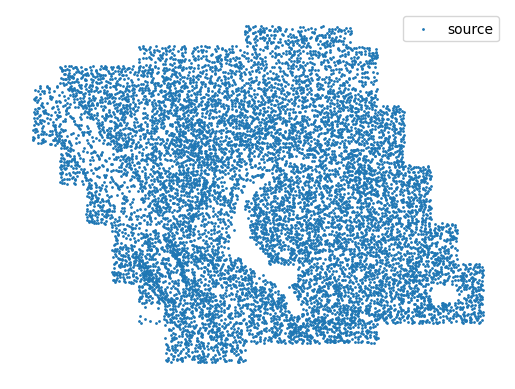

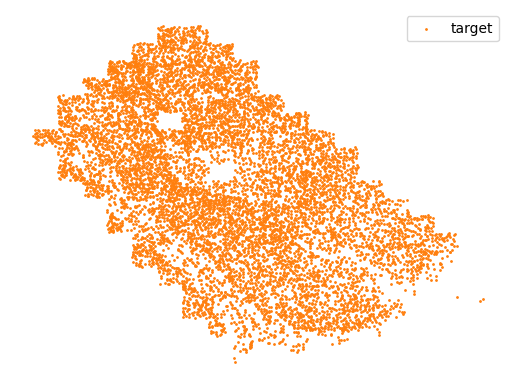

In [18]:
data_dir = './data/Mouse_brain_MERFISH_imputed/'
filePath = './local_data/incent'
save_dir = "./local_data"

age_start='4'
age_end='24'

data1=f"adata{age_start}wk_donor_id_4_slice_2"
data2=f"adata{age_end}wk_donor_id_10_slice_2"



sliceA_raw, sliceB_raw = load_data(data_dir, data1, data2)

sliceA, sliceB = compute_age_progression_score(sliceA_raw, sliceB_raw, data1, data2, filePath)


In [19]:
# save_top_correlated_genes(sliceA_raw, data1, save_dir, highly_variable_genes=50)
# save_top_correlated_genes(sliceB_raw, data2, save_dir, highly_variable_genes=50)

### Show Box plot

In [20]:
# plot_age_progression_score_boxplot(sliceA, age_start, age_end)


### Heatmap of Age progression score by cell type

In [21]:
# def save_heatmaps(sliceA, save_dir, age_start, age_end):
#     '''
#     Saves the heatmaps of age progression score for each cell type
#     '''
#     heatmap_save_dir = f'{save_dir}/age-prog-score/heatmap/{age_start}_{age_end}'

#     if not os.path.exists(heatmap_save_dir):
#         os.makedirs(heatmap_save_dir)

#     unique_cell_types = sliceA.obs['cell_type_annot'].unique()
#     for cell_type in unique_cell_types:

#         df_cell_type = sliceA[sliceA.obs['cell_type_annot'] == cell_type]
#         plt.figure(figsize=(10,10))
#         plt.scatter(sliceA.obsm["spatial"][:, 0], sliceA.obsm["spatial"][:, 1], c = 'gray', s= 2, alpha=.2)
#         custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["orange", "darkorange", "red", "darkred", "purple", "black"])
#         plt.scatter(df_cell_type.obsm["spatial"][:, 0], df_cell_type.obsm["spatial"][:, 1], s=20, c=df_cell_type.obs['age_progression_score'], cmap=custom_cmap)
#         plt.title(f'Age Progression Score Heatmap for {cell_type}')
#         plt.axis("off")
#         plt.colorbar()
#         plt.savefig(f'{heatmap_save_dir}/{cell_type}.png')
#         plt.clf()

#     print("Heatmaps saved in ", heatmap_save_dir)

# save_heatmaps(sliceA, save_dir, age_start, age_end)

### Run Relation Between Neighborhood Count and Age Progression Score

In [22]:
# run_relation_betwn_neighbor_age_prog_score(sliceA, age_start, age_end, save_dir=save_dir)

### Run Spatial DE

In [23]:
# run_spatialde_analysis(sliceA, age=f'{age_start}_{age_end}', save_dir=save_dir)

### Run SVR Model

In [24]:
# run_svr(sliceA, data1, data2, save_dir=save_dir)

In [25]:
# sc.read('/home/nuwaisir/Corridor/incent-reproducibility/data/Mouse_brain_MERFISH_imputed/adata4wk_donor_id_4_slice_1.h5ad')

# Generating image for each sample

In [26]:
data_dir = './data/Mouse_brain_MERFISH_imputed'
# filePath = './local_data/incent'
# save_dir = "./local_data"
adata_file_paths = glob(f'{data_dir}/*.h5*')

adata = sc.read(adata_file_paths[0])
cell_types = list(adata.obs['cell_type_annot'].unique())
map_cell_type_num = dict(zip(cell_types, np.arange(len(cell_types))))

for adata_file_path in adata_file_paths:
    adata = sc.read_h5ad(adata_file_path)
    
    age_wk = adata_file_path.split('/')[-1].split('wk')[0].split('adata')[-1]
    donor_id = adata_file_path.split('/')[-1].split('donor_id_')[-1].split('_')[0]
    slice = adata_file_path.split('/')[-1].split('slice_')[-1].split('.')[0]
    plt.figure(figsize=(10, 10))
    plt.axis('off')
    plt.scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1], c=list(map(lambda x: map_cell_type_num[x], adata.obs['cell_type_annot'].values)), s=4)
    save_file_path = f'{data_dir}/scatter_plots/age_{age_wk}wk_donor_{donor_id}_slice_{slice}.jpg'
    os.makedirs(os.path.dirname(save_file_path), exist_ok=True)
    plt.savefig(save_file_path)
    # plt.show()
    plt.gca()
    plt.close()



# Genrating Box Plots

In [28]:
# data_dir = './data/Mouse_brain_MERFISH_imputed'
# single_samples = [
#     f'{data_dir}/adata4wk_donor_id_8_slice_1.h5ad',
#     f'{data_dir}/adata90wk_donor_id_6_slice_0.h5ad',
#     f'{data_dir}/adata90wk_donor_id_5_slice_0.h5ad',
#     f'{data_dir}/adata4wk_donor_id_8_slice_2.h5ad',
#     f'{data_dir}/adata4wk_donor_id_4_slice_1.h5ad',
#     f'{data_dir}/adata24wk_donor_id_10_slice_2.h5ad',
#     f'{data_dir}/adata24wk_donor_id_11_slice_2.h5ad',
#     f'{data_dir}/adata4wk_donor_id_7_slice_2.h5ad',
#     f'{data_dir}/adata4wk_donor_id_8_slice_0.h5ad',
#     f'{data_dir}/adata90wk_donor_id_5_slice_1.h5ad',
#     f'{data_dir}/adata90wk_donor_id_5_slice_2.h5ad',
#     f'{data_dir}/adata4wk_donor_id_4_slice_2.h5ad',
#     f'{data_dir}/adata90wk_donor_id_6_slice_2.h5ad',
#     f'{data_dir}/adata24wk_donor_id_10_slice_1.h5ad',
#     f'{data_dir}/adata4wk_donor_id_4_slice_0.h5ad',
#     f'{data_dir}/adata90wk_donor_id_6_slice_1.h5ad'
#     f'{data_dir}/adata4wk_donor_id_7_slice_0.h5ad',
#     f'{data_dir}/adata4wk_donor_id_7_slice_1.h5ad',
#     f'{data_dir}/adata90wk_donor_id_9_slice_0.h5ad',
#     f'{data_dir}/adata24wk_donor_id_10_slice_0.h5ad',
#     f'{data_dir}/adata24wk_donor_id_11_slice_0.h5ad',
#     f'{data_dir}/adata90wk_donor_id_9_slice_1.h5ad',
# ]

data_dir = './data/Mouse_brain_MERFISH_imputed'

single_samples = [
    f'{data_dir}/adata4wk_donor_id_4_slice_0.h5ad',
    f'{data_dir}/adata4wk_donor_id_4_slice_1.h5ad',
    f'{data_dir}/adata4wk_donor_id_4_slice_2.h5ad',
    f'{data_dir}/adata4wk_donor_id_7_slice_0.h5ad',
    f'{data_dir}/adata4wk_donor_id_7_slice_1.h5ad',
    f'{data_dir}/adata4wk_donor_id_7_slice_2.h5ad',
    f'{data_dir}/adata4wk_donor_id_8_slice_0.h5ad',
    f'{data_dir}/adata4wk_donor_id_8_slice_1.h5ad',
    f'{data_dir}/adata4wk_donor_id_8_slice_2.h5ad',
    f'{data_dir}/adata24wk_donor_id_10_slice_0.h5ad',
    f'{data_dir}/adata24wk_donor_id_10_slice_1.h5ad',
    f'{data_dir}/adata24wk_donor_id_10_slice_2.h5ad',
    f'{data_dir}/adata24wk_donor_id_11_slice_0.h5ad',
    f'{data_dir}/adata24wk_donor_id_11_slice_2.h5ad',
    f'{data_dir}/adata90wk_donor_id_2_slice_0.h5ad',
    f'{data_dir}/adata90wk_donor_id_5_slice_0.h5ad'
    f'{data_dir}/adata90wk_donor_id_5_slice_1.h5ad',
    f'{data_dir}/adata90wk_donor_id_5_slice_2.h5ad',
    f'{data_dir}/adata90wk_donor_id_6_slice_0.h5ad',
    f'{data_dir}/adata90wk_donor_id_6_slice_1.h5ad',
    f'{data_dir}/adata90wk_donor_id_6_slice_2.h5ad',
    f'{data_dir}/adata90wk_donor_id_9_slice_0.h5ad',
    f'{data_dir}/adata90wk_donor_id_9_slice_1.h5ad',
    f'{data_dir}/adata90wk_donor_id_9_slice_2.h5ad',
]

In [29]:
filePath = './local_data/incent'
save_dir = "./local_data"

adata_4wk_file_paths = glob(f'{data_dir}/adata4wk*')
adata_24wk_file_paths = glob(f'{data_dir}/adata24wk*')
adata_90wk_file_paths = glob(f'{data_dir}/adata90wk*')

adata_4wk_file_paths_single = [file_path for file_path in adata_4wk_file_paths if file_path in single_samples]
adata_24wk_file_paths_single = [file_path for file_path in adata_24wk_file_paths if file_path in single_samples]
adata_90wk_file_paths_single = [file_path for file_path in adata_90wk_file_paths if file_path in single_samples]

map_age_to_file_paths_single = {
    '4': adata_4wk_file_paths_single,
    '24': adata_24wk_file_paths_single,
    '90': adata_90wk_file_paths_single,
}

age_start_end_pairs = [('4', '24'), ('24', '90')]

adata = sc.read(adata_24wk_file_paths_single[0])
box_plot_color_map = get_color_map(adata)
    
df_4_24 = pd.DataFrame()
df_24_90 = pd.DataFrame()

for age_start_end_end_pair in age_start_end_pairs:
    age_start = age_start_end_end_pair[0]
    age_end = age_start_end_end_pair[1]
    for file_path_1 in map_age_to_file_paths_single[age_start]:
        for file_path_2 in map_age_to_file_paths_single[age_end]:
            data1=file_path_1.split('/')[-1].split('.')[0]
            data2=file_path_2.split('/')[-1].split('.')[0]
            slice_1 = data1.split('_')[-1]
            slice_2 = data2.split('_')[-1]
            if slice_1 == slice_2:
                if data_dir[-1] != '/': data_dir += '/'
                sliceA_raw, sliceB_raw = load_data(data_dir, data1, data2, show=False)
                sliceA, sliceB = compute_age_progression_score(sliceA_raw, sliceB_raw, data1, data2, filePath)
                
                if age_start == '4' and age_end == '24':
                    # reference_sample_A = data2
                    # df_slice_info_A = sliceA.obs[['age', 'donor_id', 'slice', 'cell_type_annot', 'age_progression_score']]
                    # df_slice_info_A['reference_sample'] = reference_sample_A
                    # df_slice_info_A['self_sample'] = data1
                    # df_4_24 = pd.concat([df_4_24, df_slice_info_A])
                    
                    reference_sample_B = data1
                    df_slice_info_B = sliceB.obs[['age', 'donor_id', 'slice', 'cell_type_annot', 'age_progression_score']]
                    df_slice_info_B['reference_sample'] = reference_sample_B
                    df_slice_info_B['self_sample'] = data2
                    df_4_24 = pd.concat([df_4_24, df_slice_info_B])
                    
                
                if age_start == '24' and age_end == '90':
                    # reference_sample_A = data2
                    # df_slice_info_A = sliceA.obs[['age', 'donor_id', 'slice', 'cell_type_annot', 'age_progression_score']]
                    # df_slice_info_A['reference_sample'] = reference_sample_A
                    # df_slice_info_A['self_sample'] = data1
                    # df_24_90 = pd.concat([df_24_90, df_slice_info_A])
                    
                    reference_sample_B = data1
                    df_slice_info_B = sliceB.obs[['age', 'donor_id', 'slice', 'cell_type_annot', 'age_progression_score']]
                    df_slice_info_B['reference_sample'] = reference_sample_B
                    df_slice_info_B['self_sample'] = data2
                    df_24_90 = pd.concat([df_24_90, df_slice_info_B])
                    
                    
                    
                # sliceA.obs['age_progression_score']
                # plot_age_progression_score_boxplot(sliceA, age_start, age_end, box_plot_color_map, f'./analyses/age_prog_score_box_plots/{data1}_vs_{data2}_1.jpg', show=False)
                # plot_age_progression_score_boxplot(sliceB, age_start, age_end, box_plot_color_map, f'./analyses/age_prog_score_box_plots/{data1}_vs_{data2}_2.jpg', show=False)


/tmp/ipykernel_12466/2209619943.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice_info_B['reference_sample'] = reference_sample_B
/tmp/ipykernel_12466/2209619943.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice_info_B['self_sample'] = data2
/tmp/ipykernel_12466/2209619943.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

In [31]:
df_4_24.to_csv('./local_data/age-prog-score/score_4_24_imputed.csv')
df_24_90.to_csv('./local_data/age-prog-score/score_24_90_imputed.csv')

/home/nuwaisir/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/nuwaisir/.local/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/nuwaisir/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/nuwaisir/.local/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is d

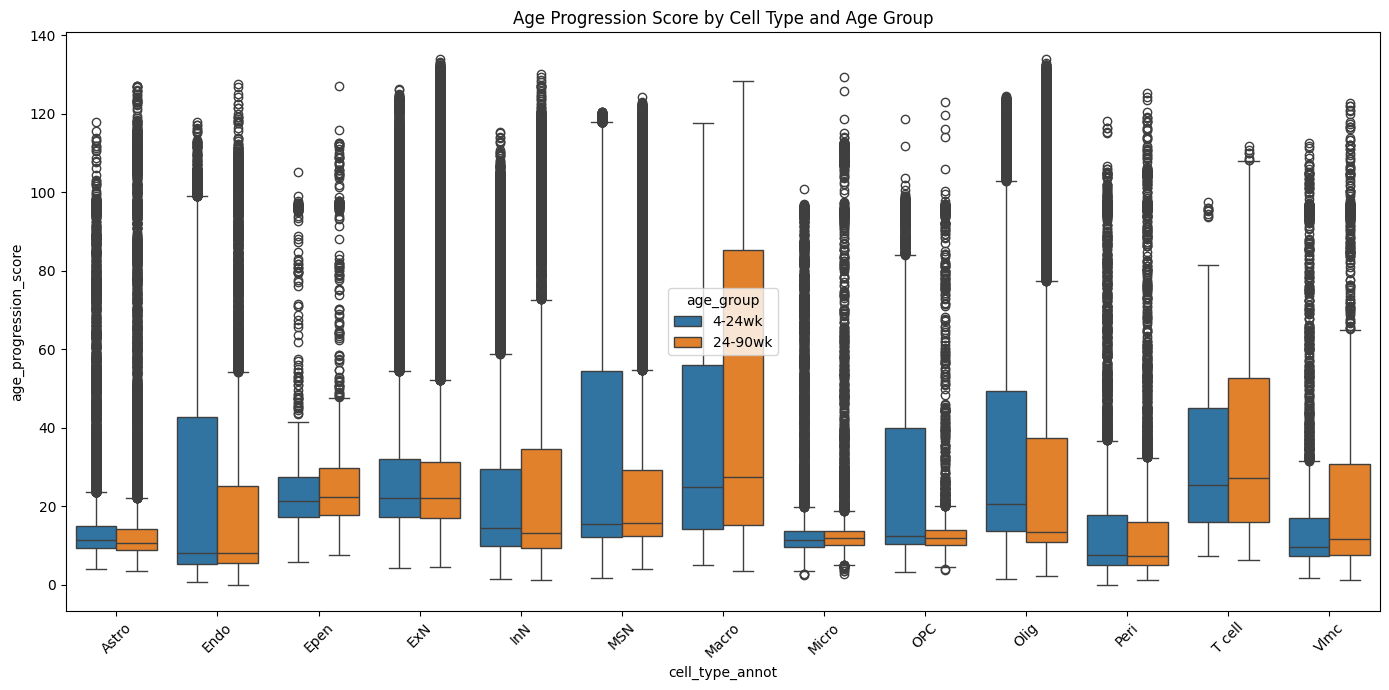

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you already have two DataFrames
# df_4_24 and df_24_90 (based on your screenshot)

# Add a column to label which group they belong to
df_4_24['age_group'] = '4-24wk'
df_24_90['age_group'] = '24-90wk'

# Concatenate the two
df_all = pd.concat([df_4_24, df_24_90], ignore_index=True)

# Plot: One boxplot per cell type, with hue showing age group
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_all,
    x='cell_type_annot',
    y='age_progression_score',
    hue='age_group'
)

plt.xticks(rotation=45)
plt.title('Age Progression Score by Cell Type and Age Group')
plt.tight_layout()
plt.show()


In [ ]:
df_all[df_all['age'] == '4wk']

,age,donor_id,slice,cell_type_annot,age_progression_score,age_group
0,4wk,MsBrainAgingSpatialDonor_8,1,Olig,58.922284,4-24wk
1,4wk,MsBrainAgingSpatialDonor_8,1,Astro,51.185751,4-24wk
2,4wk,MsBrainAgingSpatialDonor_8,1,Olig,62.398644,4-24wk
3,4wk,MsBrainAgingSpatialDonor_8,1,Olig,67.966102,4-24wk
4,4wk,MsBrainAgingSpatialDonor_8,1,ExN,74.977539,4-24wk
...,...,...,...,...,...,...
483553,90wk,MsBrainAgingSpatialDonor_9,0,Astro,63.549471,24-90wk
483554,90wk,MsBrainAgingSpatialDonor_9,0,OPC,73.164352,24-90wk
483555,90wk,MsBrainAgingSpatialDonor_9,0,Endo,84.268285,24-90wk
483556,90wk,MsBrainAgingSpatialDonor_9,0,Astro,71.972794,24-90wk
